In [7]:
import tensorflow as tf 
from tensorflow import keras

import numpy as np 
import matplotlib.pyplot as plt 
import os 
import warnings

warnings.filterwarnings("ignore")

print(tf.__version__) # 텐서플로우 버전 확인(2.19.0)

# mnist 데이터셋 로드

mnist = keras.datasets.mnist 
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(len(x_train)) # 훈련 이미지 개수 : 60,000
print(len(x_test)) # 테스트 이미지 개수 : 10,000
print(x_train.shape, y_train.shape) # 훈련 이미지의 형태 : (60000, 28, 28), 훈련 레이블의 형태 : (60000,)
print(x_test.shape, y_test.shape) # 테스트 이미지의 형태 : (10000, 28, 28), 테스트 레이블의 형태 : (10000,)

2.19.0
60000
10000
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


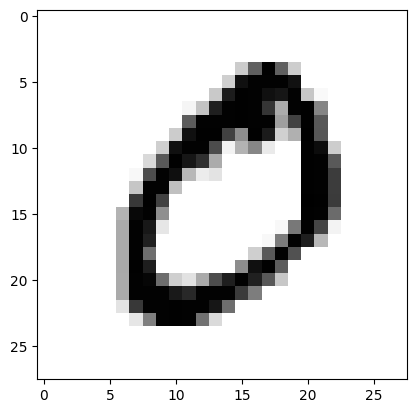

In [10]:
plt.imshow(x_train[1], cmap=plt.cm.binary)
plt.show()

In [12]:
print(y_train[1])

0


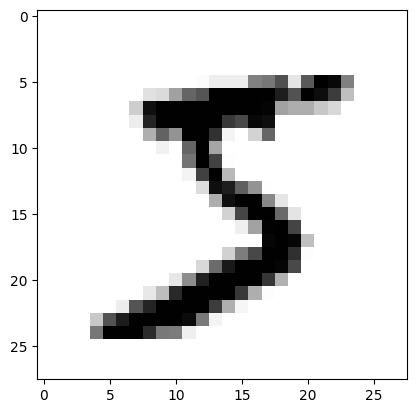

1 번째 이미지의 숫자는 바로 5 입니다.


In [15]:
index = 0
plt.imshow(x_train[index], cmap = plt.cm.binary)
plt.show()
print( (index+1), '번째 이미지의 숫자는 바로', y_train[index], '입니다.')

In [16]:
print('최소값:', np.min(x_train))
print('최대값:', np.max(x_train))

최소값: 0
최대값: 255


In [17]:
x_train_norm, x_test_norm = x_train / 255.0, x_test / 255.0
print('최소값:', np.min(x_train_norm))
print('최대값:', np.max(x_train_norm))

최소값: 0.0
최대값: 1.0


In [19]:
model=keras.models.Sequential()
model.add(keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(keras.layers.MaxPool2D(2,2))
model.add(keras.layers.Conv2D(32, (3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(32, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

print('Model에 추가된 Layer 개수 : ', len(model.layers))

Model에 추가된 Layer 개수 :  7


In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,762 (120.16 KB)

 Trainable params: 30,762 (120.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# reshape를 통해 채널개수 추가
print(f"Before Reshape - x_train_norm shape: {x_train_norm.shape}")
print(f"Before Reshape - x_test_norm shape: {x_test_norm.shape}")

x_train_reshaped = x_train_norm.reshape(-1, 28, 28, 1)
x_test_reshaped = x_test_norm.reshape(-1, 28, 28, 1)

print(f"After Reshape - x_train_reshaped shape: {x_train_reshaped.shape}")
print(f"After Reshape - x_test_reshaped shape: {x_test_reshaped.shape}")

Before Reshape - x_train_norm shape: (60000, 28, 28)
Before Reshape - x_test_norm shape: (10000, 28, 28)
After Reshape - x_train_reshaped shape: (60000, 28, 28, 1)
After Reshape - x_test_reshaped shape: (10000, 28, 28, 1)


In [22]:
# 딥러닝 네트워크 훈련
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train_reshaped, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8694 - loss: 0.4213
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9780 - loss: 0.0707
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9859 - loss: 0.0465
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9891 - loss: 0.0363
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9926 - loss: 0.0256
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9928 - loss: 0.0233
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9942 - loss: 0.0188
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9950 - loss: 0.0148
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9956 - loss: 0.0147
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9961 - loss: 0.0114


In [23]:
# 테스트
test_loss, test_accuracy = model.evaluate(x_test_reshaped, y_test, verbose=2)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

313/313 - 0s - 844us/step - accuracy: 0.9909 - loss: 0.0300
Test Loss: 0.03000819683074951
Test Accuracy: 0.9908999800682068


In [24]:
# 점수가 낮아진 이유 찾아보기
predicted_result = model.predict(x_test_reshaped)
predicted_labels = np.argmax(predicted_result, axis=1)

idx = 0
print('model.predict() 결과: ', predicted_result[idx])
print('model이 추론한 가장 가능성이 높은 결과 : ', predicted_labels[idx])
print('실제 데이터의 라벨 : ', y_test[idx])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step
model.predict() 결과:  [5.4313123e-09 1.0449448e-10 9.1510651e-07 1.6388393e-09 5.0206048e-09
 8.3633485e-14 1.3947133e-14 9.9999905e-01 3.0311498e-13 1.6659186e-08]
model이 추론한 가장 가능성이 높은 결과 :  7
실제 데이터의 라벨 :  7


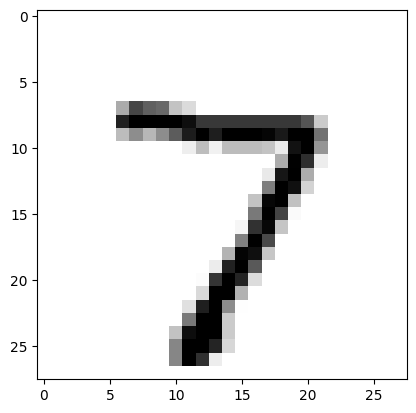

In [26]:
plt.imshow(x_test[idx], cmap=plt.cm.binary)
plt.show()

예측확률분포: [4.0755028e-01 7.8274979e-07 3.1643751e-04 6.4369556e-07 2.7665974e-05
 2.3761688e-08 2.0074083e-06 3.2120818e-04 5.9038651e-01 1.3945092e-03]
라벨: 0, 예측결과 : 8


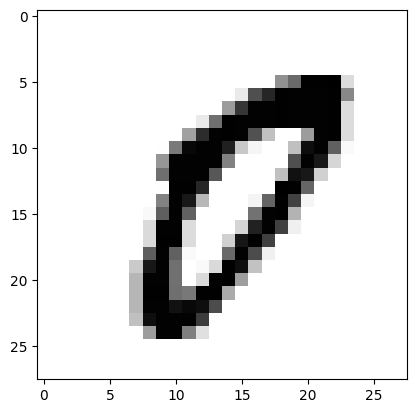

예측확률분포: [3.1731464e-08 6.2198550e-03 4.8811402e-04 3.9793329e-05 5.0391041e-04
 1.1301091e-04 7.0472483e-10 3.0347678e-01 2.6383193e-03 6.8652010e-01]
라벨: 7, 예측결과 : 9


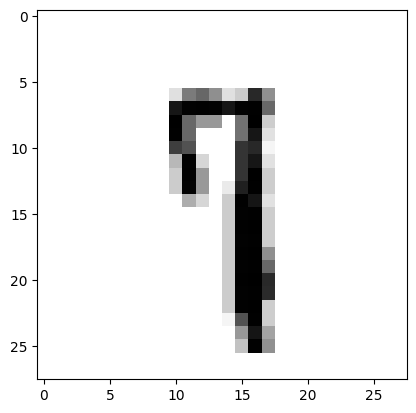

예측확률분포: [3.1033995e-02 1.9867456e-07 1.0018918e-02 2.6835594e-02 3.9934848e-06
 8.1991649e-04 2.7677272e-09 5.4388291e-01 1.1913927e-04 3.8728544e-01]
라벨: 0, 예측결과 : 7


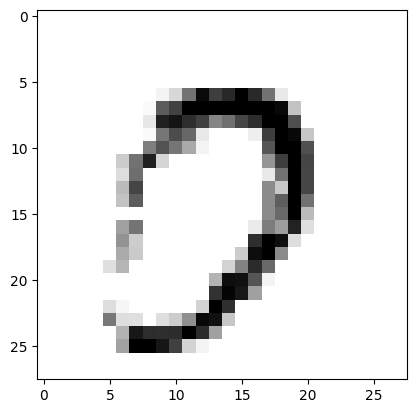

예측확률분포: [1.7548092e-09 7.8943231e-06 8.8591886e-01 1.7271405e-07 5.6539641e-08
 6.4545136e-13 2.8046048e-09 1.1407302e-01 4.5105408e-10 8.7787606e-14]
라벨: 7, 예측결과 : 2


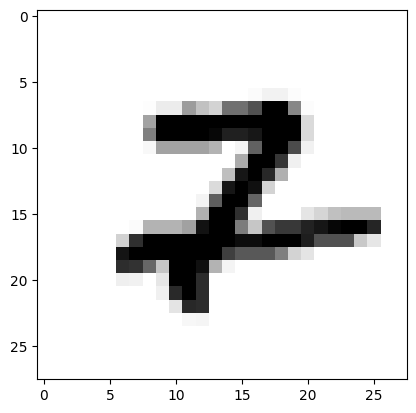

예측확률분포: [4.3306066e-04 3.8053291e-10 7.8946905e-06 4.7580299e-05 6.5775014e-02
 1.3944463e-04 2.1617173e-04 1.1177186e-06 6.2031806e-01 3.1306165e-01]
라벨: 9, 예측결과 : 8


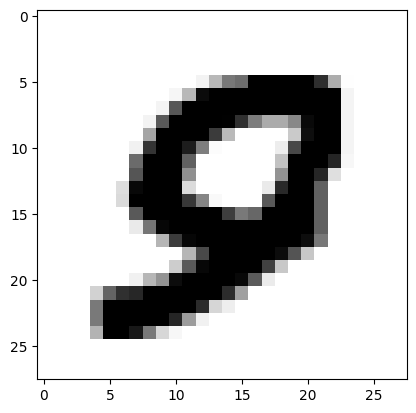

In [27]:
# 모델이 추론해 낸 결과와 실제 라벨이 다른 경우 확인
import random
wrong_predict_list = []

for i, _ in enumerate(predicted_labels):
    
    if predicted_labels[i] != y_test[i]:
        wrong_predict_list.append(i)

samples = random.choices(population=wrong_predict_list, k=5)

for n in samples:
    print("예측확률분포: " + str(predicted_result[n]))
    print("라벨: " + str(y_test[n]) + ", 예측결과 : "+ str(predicted_labels[n]))
    plt.imshow(x_test[n], cmap=plt.cm.binary)
    plt.show()

In [33]:
# 성능향상을 위해 파라미터 조정
n_channel_1 = 8
n_channel_2 = 16
n_dense = 32
n_train_epoch = 10

model=keras.models.Sequential()
model.add(keras.layers.Conv2D(n_channel_1, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(keras.layers.MaxPool2D((2,2)))
model.add(keras.layers.Conv2D(n_channel_2, (3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(n_dense, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

model.summary()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train_reshaped, y_train, epochs=n_train_epoch)

test_loss, test_accuracy = model.evaluate(x_test_reshaped, y_test, verbose=2)
print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,410 (56.29 KB)

 Trainable params: 14,410 (56.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8476 - loss: 0.5080
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9714 - loss: 0.0913
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9809 - loss: 0.0622
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9839 - loss: 0.0515
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9873 - loss: 0.0414
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9879 - loss: 0.0372
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9897 - loss: 0.0314
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9918 - loss: 0.0264
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9930 - loss: 0.0218
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9933 - loss: 0.0209
313/313 - 0s - 807us/step - accuracy: 0.9866 - loss: 0.0421
Test loss: 0.04210875183343887
Test accuracy: 0.98659998178